# Citation
Sravan Pannala et al "Consistently Tuned Battery Lifetime Predictive Model of Capacity Loss, Resistance Increase, and Irreversible Thickness Growth" J. Electrochem. Soc. 171 010532 (2024)  
Section: Degradation Model Tuning Process

In [1]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)

eSOH_DIR = "./data/"
oCV_DIR = "./data/"

In [2]:
# get parameter values
parameter_values = get_parameter_values()
# define model
spm = pybamm.lithium_ion.SPM(
    {
        "SEI": "ec reaction limited",
        "loss of active material": "stress-driven",
        "lithium plating": "irreversible",
        "stress-induced diffusion": "false",
    }
)
#model internal parameters
param=spm.param

## Tuning

In [3]:
cells = [1,4,10]
irrev_exp_data=[]
del_sei=[]; del_li=[]; es_ic_n=[]; es_ic_p=[];
for cell in cells:
    # load the data for each cell
    cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
    Ns = np.insert(N[1:]-1,0,0)
    # get parameters to intialize the model
    eps_n_data,eps_p_data,c_rate_c,c_rate_d,dis_set,Temp,SOC_0 = init_exp(cell_no,dfe,spm,parameter_values)
    experiment = pybamm.Experiment(
        [
            ("Discharge at "+c_rate_d+dis_set,
            "Rest for 10 sec",
            "Charge at "+c_rate_c+" until 4.2V", 
            "Hold at 4.2V until C/100")
        ] *dfe.N.iloc[-1],
        termination="50% capacity",
    #     cccv_handling="ode",
    )
   
    parameter_values.update(
        {
            "Positive electrode LAM constant proportional term [s-1]": 3.6297e-08,
            "Negative electrode LAM constant proportional term [s-1]": 1.8566e-07,
            "Positive electrode LAM constant exponential term": 1.0921,
            "Negative electrode LAM constant exponential term": 1.0921,
            "Lithium plating kinetic rate constant [m.s-1]": 2.1484e-09,
            "Positive electrode LAM constant proportional term 2 [s-1]": -3.5501e-09,
            "Negative electrode LAM constant proportional term 2 [s-1]": -5.2027e-09,
            "Negative electrode active material volume fraction": eps_n_data,
            "Positive electrode active material volume fraction": eps_p_data,
            "Initial temperature [K]": 273.15+Temp,
            "Ambient temperature [K]": 273.15+Temp,
            "Negative electrode LAM min stress [Pa]": 0,
            "Negative electrode LAM max stress [Pa]": 0,
            "Positive electrode LAM min stress [Pa]": 0,
            "Positive electrode LAM max stress [Pa]": 0,
            "SEI kinetic rate constant [m.s-1]": 5.8561e-16,
            "EC diffusivity [m2.s-1]": 2.4779e-19,
            "SEI growth activation energy [J.mol-1]": 19669.2,
            "Initial inner SEI thickness [m]": 0e-09,
            "Initial outer SEI thickness [m]": 5e-09,
            "Negative electrode partial molar volume [m3.mol-1]": 7e-06,
            "Li plating resistivity [Ohm.m]": 30000.0,
            "SEI resistivity [Ohm.m]": 30000.0,
        },
        check_already_exists=False,
    )
    # simulate the model
    df = cycle_adaptive_simulation_V2(spm, parameter_values, experiment,SOC_0, save_at_cycles=1)
    # SEI layer thickness
    del_sei = np.append(del_sei,(df["X-averaged SEI thickness [m]"][Ns]-df["X-averaged SEI thickness [m]"][0]))
    # Plated Lithium thickness
    del_li = np.append(del_li,df["X-averaged lithium plating thickness [m]"][Ns])
    # negative electode inactive material
    es_ic_n = np.append(es_ic_n,(-df["X-averaged negative electrode active material volume fraction"][Ns]+df["X-averaged negative electrode active material volume fraction"][0]))
    # positive electrode inactive material 
    es_ic_p = np.append(es_ic_p,(-df["X-averaged positive electrode active material volume fraction"][Ns]+df["X-averaged positive electrode active material volume fraction"][0])) 
    irrev_exp_data = np.append(irrev_exp_data,dfe["irrev_exp"].to_numpy())

CasADi - 2024-03-22 07:43:30 WARNING("The options 't0', 'tf', 'grid' and 'output_t0' have been deprecated.
The same functionality is provided by providing additional input arguments to the 'integrator' function, in particular:
 * Call integrator(..., t0, tf, options) for a single output time, or
 * Call integrator(..., t0, grid, options) for multiple grid points.
The legacy 'output_t0' option can be emulated by including or excluding 't0' in 'grid'.
Backwards compatibility is provided in this release only.") [.../casadi/core/integrator.cpp:515]


In [ ]:
# cost function for tuning resistance
def fitfunc3(X,b1, b2, b3, b4):
  ln = 6.2e-05
  lp = 6.7e-05
  del_sei,del_li2,es_ic_n,es_ic_p=X
  # equation 57 in paper
  out = (b1*del_sei*1e6+b2*del_li2*1e12+b3*es_ic_n+b4*es_ic_p)
  return out

In [ ]:
# initial guesss
ig = (100,1000,1000,1000)
# lower bound
lb = 0
# upper bound
ub = [1e5,1e5,1e15,1e15]
# tune expansion coefficients
popt1, pcov1 = curve_fit(fitfunc3, (del_sei,del_li**2,es_ic_n,es_ic_p), irrev_exp_data,p0=ig,bounds=(lb,ub))

In [4]:
b1_fit = round(popt1[0],2)
b2_fit = round(popt1[1],2)
b3_fit = round(popt1[2],2)
b4_fit = round(popt1[3],2)
# print output
print(f"b1 fit:{b1_fit}, b2 fit:{b2_fit}, b3 fit:{b3_fit}, b4 fit:{b4_fit}")

b1 fit:447.96, b2 fit:13419.47, b3 fit:440.35, b4 fit:0.0


## Simulate Results to Verify

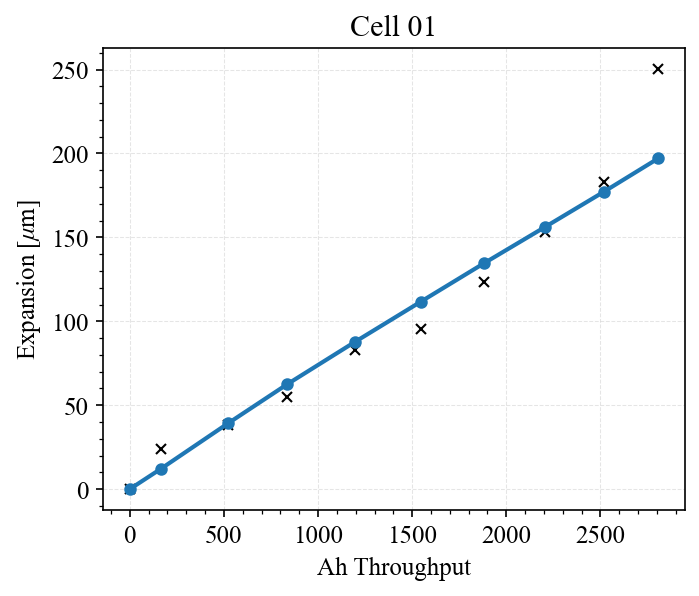

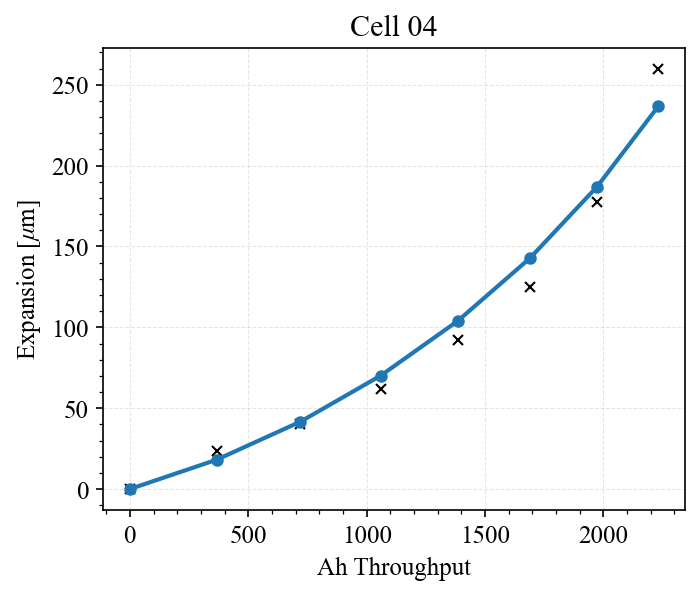

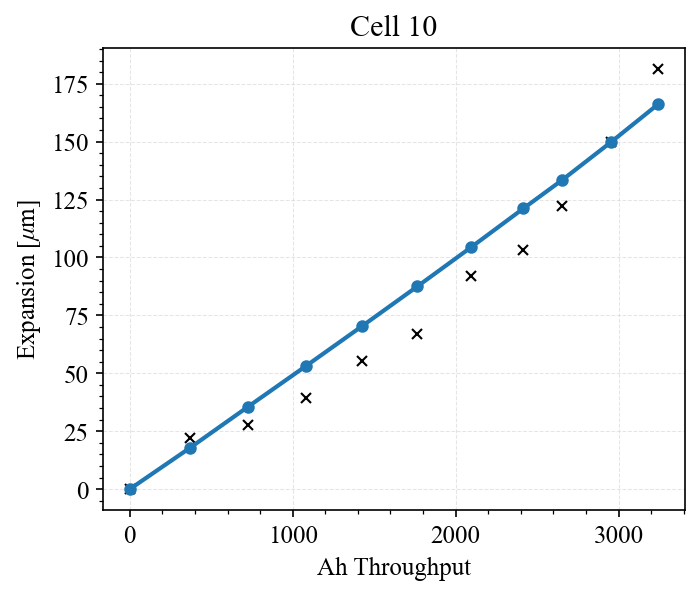

In [5]:
cells = [1,4,10]
irrev_exp_data=[]
del_sei=[]; del_li=[]; es_ic_n=[]; es_ic_p=[];
for cell in cells:
    # load the data for each cell
    cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
    Ns = np.insert(N[1:]-1,0,0)
    # get parameters to intialize the model
    eps_n_data,eps_p_data,c_rate_c,c_rate_d,dis_set,Temp,SOC_0 = init_exp(cell_no,dfe,spm,parameter_values)
    experiment = pybamm.Experiment(
        [
            ("Discharge at "+c_rate_d+dis_set,
            "Rest for 10 sec",
            "Charge at "+c_rate_c+" until 4.2V", 
            "Hold at 4.2V until C/100")
        ] *dfe.N.iloc[-1],
        termination="50% capacity",
    #     cccv_handling="ode",
    )
   
    parameter_values.update(
        {
            "Positive electrode LAM constant proportional term [s-1]": 3.6297e-08,
            "Negative electrode LAM constant proportional term [s-1]": 1.8566e-07,
            "Positive electrode LAM constant exponential term": 1.0921,
            "Negative electrode LAM constant exponential term": 1.0921,
            "Lithium plating kinetic rate constant [m.s-1]": 2.1484e-09,
            "Positive electrode LAM constant proportional term 2 [s-1]": -3.5501e-09,
            "Negative electrode LAM constant proportional term 2 [s-1]": -5.2027e-09,
            "Negative electrode active material volume fraction": eps_n_data,
            "Positive electrode active material volume fraction": eps_p_data,
            "Initial temperature [K]": 273.15+Temp,
            "Ambient temperature [K]": 273.15+Temp,
            "Negative electrode LAM min stress [Pa]": 0,
            "Negative electrode LAM max stress [Pa]": 0,
            "Positive electrode LAM min stress [Pa]": 0,
            "Positive electrode LAM max stress [Pa]": 0,
            "SEI kinetic rate constant [m.s-1]": 5.8561e-16,
            "EC diffusivity [m2.s-1]": 2.4779e-19,
            "SEI growth activation energy [J.mol-1]": 19669.2,
            "Initial inner SEI thickness [m]": 0e-09,
            "Initial outer SEI thickness [m]": 5e-09,
            "Negative electrode partial molar volume [m3.mol-1]": 7e-06,
            "Li plating resistivity [Ohm.m]": 30000.0,
            "SEI resistivity [Ohm.m]": 30000.0,
        },
        check_already_exists=False,
    )
    # simulate the model
    df = cycle_adaptive_simulation_V2(spm, parameter_values, experiment,SOC_0, save_at_cycles=1)
    # SEI layer thickness
    del_sei = df["X-averaged SEI thickness [m]"][Ns]-df["X-averaged SEI thickness [m]"][0]
    # Plated Lithium thickness
    del_li = df["X-averaged lithium plating thickness [m]"][Ns]
    # negative electode inactive material
    es_ic_n = -df["X-averaged negative electrode active material volume fraction"][Ns]+df["X-averaged negative electrode active material volume fraction"][0]
    # positive electrode inactive material 
    es_ic_p = -df["X-averaged positive electrode active material volume fraction"][Ns]+df["X-averaged positive electrode active material volume fraction"][0]
    irrev_exp_data = dfe["irrev_exp"].to_numpy()
    # equation 57 in paper
    irrev_exp = (b1_fit*del_sei*1e6+b2_fit*del_li**2*1e12+b3_fit*es_ic_n+b4_fit*es_ic_p)
    fig,ax = plt.subplots(1,1,figsize=(5,4))
    ax.plot(dfe["Ah_th"],irrev_exp_data,'kx')
    ax.plot(dfe["Ah_th"],irrev_exp,'o-')
    ax.set_xlabel('Ah Throughput')
    ax.set_ylabel(r"Expansion [$\mu$m]")
    ax.set_title(f"Cell {cell_no}")